In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

In [ ]:
pengangguran = pd.read_excel('/content/tingkat_pengangguran_terbuka_2023 (1).xlsx')
kemiskinan = pd.read_excel('/content/persentase_penduduk_miskin_2023 (1).xlsx')
penduduk = pd.read_excel('/content/jumlah_penduduk_indonesia_2023 (1).xlsx')
pendidikan = pd.read_excel('/content/TPP_BPS_20233 (1).xlsx', header=2)

In [ ]:
# Data Cleaning & Preprocessing

# Pengangguran
pengangguran = pengangguran.rename(columns={
    pengangguran.columns[0]: 'Provinsi',
    pengangguran.columns[1]: 'Pengangguran'
})
pengangguran['Pengangguran'] = pd.to_numeric(pengangguran['Pengangguran'], errors='coerce')
pengangguran = pengangguran.dropna(subset=['Provinsi', 'Pengangguran'])
pengangguran['Provinsi'] = pengangguran['Provinsi'].str.upper()
pengangguran = pengangguran[['Provinsi', 'Pengangguran']]

# Kemiskinan
kemiskinan = kemiskinan.rename(columns={
    kemiskinan.columns[0]: 'Provinsi',
    kemiskinan.columns[1]: 'Kemiskinan'
})
kemiskinan['Kemiskinan'] = pd.to_numeric(kemiskinan['Kemiskinan'], errors='coerce')
kemiskinan = kemiskinan.dropna(subset=['Provinsi', 'Kemiskinan'])
kemiskinan['Provinsi'] = kemiskinan['Provinsi'].str.upper()
kemiskinan = kemiskinan[['Provinsi', 'Kemiskinan']]

# Pendidikan (TPP SMA/Sederajat dipakai sebagai indikator TPP)
pendidikan = pendidikan.rename(columns={
    'Provinsi': 'Provinsi',
    'TPP SMA/Sederajat (%)': 'Pendidikan'
})
pendidikan['Pendidikan'] = pd.to_numeric(pendidikan['Pendidikan'], errors='coerce')
pendidikan = pendidikan.dropna(subset=['Provinsi', 'Pendidikan'])
pendidikan['Provinsi'] = pendidikan['Provinsi'].str.upper()
pendidikan = pendidikan[['Provinsi', 'Pendidikan']]

# Penduduk
penduduk = penduduk.rename(columns={
    'Provinsi di Indonesia': 'Provinsi',
    'Jumlah Penduduk 2023 (Ribu Jiwa)': 'Penduduk'
})
penduduk['Penduduk'] = pd.to_numeric(penduduk['Penduduk'], errors='coerce')
penduduk = penduduk.dropna(subset=['Provinsi', 'Penduduk'])
penduduk['Provinsi'] = penduduk['Provinsi'].str.upper()
penduduk = penduduk[['Provinsi', 'Penduduk']]

In [ ]:
# Merge Dataset + Buang Baris Total

# Merge semua dataset
df = pengangguran.merge(kemiskinan, on='Provinsi')
df = df.merge(pendidikan, on='Provinsi')
df = df.merge(penduduk, on='Provinsi')

# Buang baris "INDONESIA" (total nasional, bukan provinsi)
df = df[df['Provinsi'] != 'INDONESIA'].reset_index(drop=True)

print(df.shape)
print(df.to_string())

(34, 5)
                Provinsi  Pengangguran  Kemiskinan  Pendidikan  Penduduk
0                   ACEH          5.75        9.79       74.46    5409.2
1         SUMATERA UTARA          5.24        8.23       74.43   15180.5
2         SUMATERA BARAT          5.90        4.67       68.64    5677.6
3                   RIAU          4.25        6.73       67.79    6555.8
4                  JAMBI          4.50       10.19       66.62    3633.2
5       SUMATERA SELATAN          4.53       11.07       64.81    8647.3
6               BENGKULU          3.21       14.21       63.41    2059.4
7                LAMPUNG          4.18        8.02       64.54    4496.6
8   KEP. BANGKA BELITUNG          3.89        3.54       68.96    1492.0
9              KEP. RIAU          7.61        5.05       78.97    2121.5
10           DKI JAKARTA          7.57        4.44       88.10   10640.0
11            JAWA BARAT          7.89        7.19       66.47   49306.8
12           JAWA TENGAH          5.24     

In [ ]:
# Normalisasi Min-Max Scaling

# Variabel untuk clustering
X = df[['Pendidikan', 'Penduduk', 'Pengangguran', 'Kemiskinan']]

# Normalisasi Min-Max Scaling (sesuai BAB III)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(pd.DataFrame(X_scaled, columns=X.columns).head())

   Pendidikan  Penduduk  Pengangguran  Kemiskinan
0    0.696553  0.096510      0.549696    0.585754
1    0.695955  0.297621      0.446247    0.439550
2    0.580594  0.102034      0.580122    0.105904
3    0.563658  0.120109      0.245436    0.298969
4    0.540347  0.059957      0.296146    0.623243


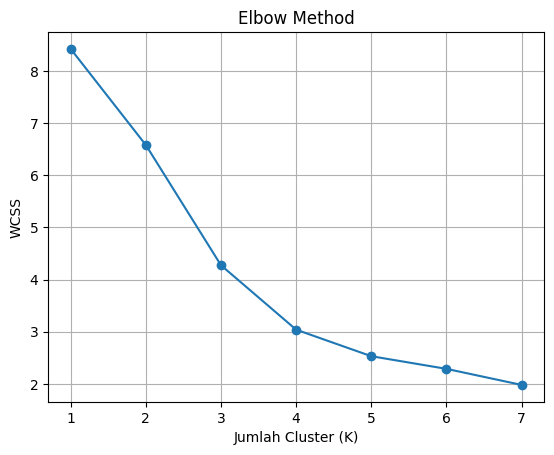

In [ ]:
# Elbow Method
wcss = []
for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 8), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
# K-Means final
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df[['Provinsi','Pendidikan','Penduduk','Pengangguran','Kemiskinan','Cluster']].to_string())

                Provinsi  Pendidikan  Penduduk  Pengangguran  Kemiskinan  Cluster
0                   ACEH       74.46    5409.2          5.75        9.79        1
1         SUMATERA UTARA       74.43   15180.5          5.24        8.23        1
2         SUMATERA BARAT       68.64    5677.6          5.90        4.67        1
3                   RIAU       67.79    6555.8          4.25        6.73        2
4                  JAMBI       66.62    3633.2          4.50       10.19        2
5       SUMATERA SELATAN       64.81    8647.3          4.53       11.07        2
6               BENGKULU       63.41    2059.4          3.21       14.21        2
7                LAMPUNG       64.54    4496.6          4.18        8.02        2
8   KEP. BANGKA BELITUNG       68.96    1492.0          3.89        3.54        2
9              KEP. RIAU       78.97    2121.5          7.61        5.05        1
10           DKI JAKARTA       88.10   10640.0          7.57        4.44        1
11            JA

In [ ]:
# Evaluasi DBI & Silhouette
dbi = davies_bouldin_score(X_scaled, df['Cluster'])
sil = silhouette_score(X_scaled, df['Cluster'])
print("DBI:", dbi)
print("Silhouette:", sil)

DBI: 0.9668688756438852
Silhouette: 0.3180189548081592


In [ ]:
# Cluster profiling
profil = df.groupby('Cluster')[['Pendidikan','Penduduk','Pengangguran','Kemiskinan']].mean()
print(profil)
print(df['Cluster'].value_counts())

         Pendidikan      Penduduk  Pengangguran  Kemiskinan
Cluster                                                    
0          64.49000  42572.400000      5.820000    8.156667
1          73.82900   6886.860000      6.394000    5.827000
2          62.18381   3544.471429      3.904286    7.567143
Cluster
2    21
1    10
0     3
Name: count, dtype: int64


In [ ]:
# Bandingkan dengan rata-rata nasional (semua provinsi)
print("Rata-rata Nasional:")
print(df[['Pendidikan','Penduduk','Pengangguran','Kemiskinan']].mean())

Rata-rata Nasional:
Pendidikan        65.812353
Penduduk        7971.167647
Pengangguran       4.805588
Kemiskinan         7.107353
dtype: float64


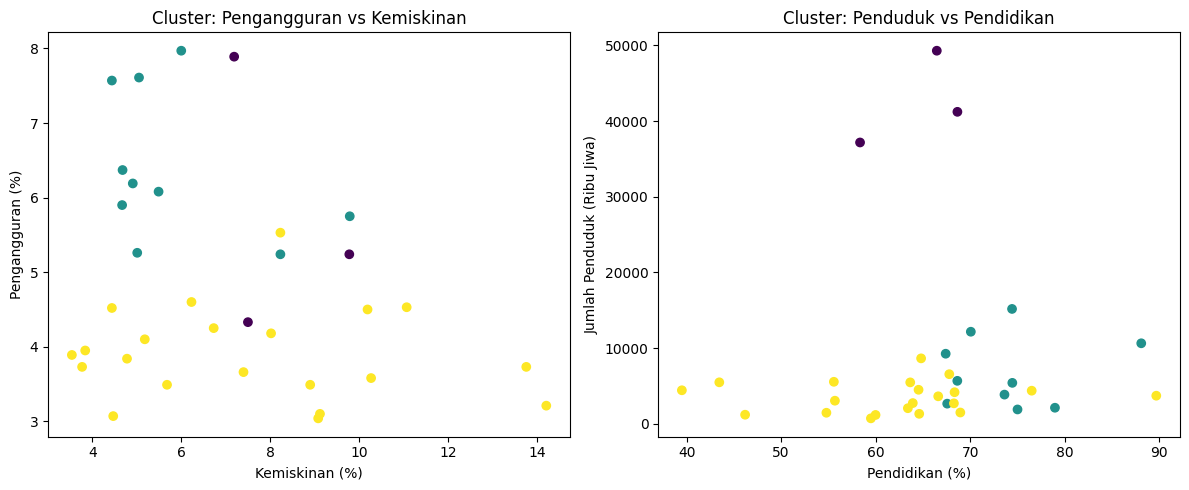

In [ ]:
# Visualisasi scatter plot
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(df['Kemiskinan'], df['Pengangguran'], c=df['Cluster'], cmap='viridis')
axes[0].set_xlabel('Kemiskinan (%)')
axes[0].set_ylabel('Pengangguran (%)')
axes[0].set_title('Cluster: Pengangguran vs Kemiskinan')

axes[1].scatter(df['Pendidikan'], df['Penduduk'], c=df['Cluster'], cmap='viridis')
axes[1].set_xlabel('Pendidikan (%)')
axes[1].set_ylabel('Jumlah Penduduk (Ribu Jiwa)')
axes[1].set_title('Cluster: Penduduk vs Pendidikan')

plt.tight_layout()
plt.show()

# ==== **Check Nilai** ====

In [ ]:
print(df[['Provinsi','Pendidikan','Penduduk','Pengangguran','Kemiskinan','Cluster']].to_string())

                Provinsi  Pendidikan  Penduduk  Pengangguran  Kemiskinan  Cluster
0                   ACEH       74.46    5409.2          5.75        9.79        1
1         SUMATERA UTARA       74.43   15180.5          5.24        8.23        1
2         SUMATERA BARAT       68.64    5677.6          5.90        4.67        1
3                   RIAU       67.79    6555.8          4.25        6.73        2
4                  JAMBI       66.62    3633.2          4.50       10.19        2
5       SUMATERA SELATAN       64.81    8647.3          4.53       11.07        2
6               BENGKULU       63.41    2059.4          3.21       14.21        2
7                LAMPUNG       64.54    4496.6          4.18        8.02        2
8   KEP. BANGKA BELITUNG       68.96    1492.0          3.89        3.54        2
9              KEP. RIAU       78.97    2121.5          7.61        5.05        1
10           DKI JAKARTA       88.10   10640.0          7.57        4.44        1
11            JA

In [ ]:
print("DBI:", davies_bouldin_score(X_scaled, df['Cluster']))
print("Silhouette:", silhouette_score(X_scaled, df['Cluster']))

DBI: 0.9668688756438852
Silhouette: 0.3180189548081592


In [ ]:
print(df.groupby('Cluster')[['Pendidikan','Penduduk','Pengangguran','Kemiskinan']].mean())
print(df['Cluster'].value_counts())

         Pendidikan      Penduduk  Pengangguran  Kemiskinan
Cluster                                                    
0          64.49000  42572.400000      5.820000    8.156667
1          73.82900   6886.860000      6.394000    5.827000
2          62.18381   3544.471429      3.904286    7.567143
Cluster
2    21
1    10
0     3
Name: count, dtype: int64


In [ ]:
print("Rata-rata Nasional:")
print(df[['Pendidikan','Penduduk','Pengangguran','Kemiskinan']].mean())

Rata-rata Nasional:
Pendidikan        65.812353
Penduduk        7971.167647
Pengangguran       4.805588
Kemiskinan         7.107353
dtype: float64
